# 2ndDataGen_Gso.ipynb — XGBoost + Greedy Sampling on the Outputs

This notebook reproduces the active learning path based on greedy sampling in the output space for the XGBoost surrogate model.

The workflow includes:
- loading the initial candidate pool and baseline model artifacts
- selecting new fluids according to output-space criteria
- incorporating newly simulated fluids in batches of two
- preprocessing and BEP-based scaling
- iterative retraining of the XGBoost model
- performance tracking as the number of fluids increases

> **Note:** Greedy sampling on the outputs was only applied to XGBoost in this study. For GPR, an uncertainty-based optimization path was used instead, maintaining a balanced comparison across the two surrogate-model families. This notebook is shared primarily to document the methodology and experimental workflow used in the study. Some data-loading steps depend on project-specific files not fully distributed in the public repository.

In [2]:
#Import the .py file with the functions 
import importlib
import joblib
import Functions_PumpAI as fun
from pyDOE2 import lhs
import numpy as np
importlib.reload(fun)

XGBoost version: 1.7.6
XGBoost version: 1.7.6


<module 'Functions_PumpAI' from '/Users/danielmorantes/PythonP/Functions_PumpAI.py'>

In [28]:
#Load the candidates pool with the physical properties (density and viscosity)
candidates_pool = joblib.load('artifacts/candidate_pool.pkl')
#Adding the mass flow rate to the candidates pool
samples_pool = candidates_pool.shape[0]
lhs_flowrate = lhs(1, samples=samples_pool, criterion='maximin')
flow_rate = lhs_flowrate[:,0]*25
rho_values = candidates_pool['rho(kg/m3)'].values
mass_flow = rho_values*0.000063090196*flow_rate
candidates_pool['massflow_dim'] = mass_flow
candidates_pool

#Save the new candidates pool with the mass flow rate
fun.save_object(candidates_pool, 'candidate_pool_with_mass_flow')

candidate_pool_with_mass_flow saved in artifacts


In [29]:
candidates_pool

,rho(kg/m3),k(Pa*s^n),n(-),FluidType,massflow_dim
0,794.611869,0.001079,1.000000,Newtonian,0.789614
1,813.874815,0.041772,1.000000,Newtonian,0.244033
2,804.381099,0.041308,1.000000,Newtonian,0.261073
3,952.286066,0.026630,1.000000,Newtonian,1.461215
4,988.233215,0.048312,1.000000,Newtonian,1.020468
...,...,...,...,...,...
2995,1017.623707,10.978893,0.459151,PowerLaw,0.619864
2996,1014.638801,4.624957,0.384555,PowerLaw,0.161321
2997,1003.244589,0.278302,0.540625,PowerLaw,0.954866
2998,1014.172248,8.316328,0.505604,PowerLaw,1.289801


In [3]:
#Load the inital bep scaled train and test data
bepscaled_initial_trainData = joblib.load('artifacts/bepscaleddf_initialDATA.pkl')
testdata_bepscaled = joblib.load('artifacts/bepscaled_testdf.pkl')

In [4]:
#Load the initial XGBoost model, scores and scaler of the data
xgb_intmodel = joblib.load('artifacts/best_xgbintdata.pkl')
xgb_intresults = joblib.load('artifacts/results_xgbintdata.pkl')
scalerx_int = joblib.load('artifacts/scaler_xbf_IntTrain.pkl')
scalery_int = joblib.load('artifacts/scaler_ybf_IntTrain.pkl')
X_train_scaledbf_Int = joblib.load('artifacts/X_train_scaledbf_IntTrain.pkl')

In [5]:
#Parameters of the XGBoost
feature_cols = ['rho(kg/m3)', 'k(Pa*s^n)', 'n(-)', 
                'massflow_dim']
target_cols = 'head_dim'
param_dist = {
    'learning_rate': [0.001, 0.01,0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5],
    'n_estimators': [100, 200, 300, 500, 700],
    'min_child_weight': [1, 5, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [0, 1, 5, 10]}
cv_folds = 25
n_iter = 500
val_size = 0.1

In [56]:
#List for models and scores during the training
xgb_modelsGSY = []
xgb_modelsGSY.append(xgb_intmodel)
xgb_scoresGSY = []

# Greedy Sampling on the outputs
- Carefully rerun the following cells, due to the same excel sheet is being augmented

**First Iteration**

In [ ]:
#Scale the candidates pool with the same scaler used for the initial data
X_candidates_scaled = scalerx_int.transform(candidates_pool[feature_cols])

/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [60]:
#Select the 2 fluids to simulate
n_selected = 2
fluids_augment, updated_pool1 = fun.greedy_sampling_outputs(xgb_intmodel, candidates_pool, 
                                                            X_train_scaledbf_Int, X_candidates_scaled, n_selected)
fluids_augment

Selected 2 new candidates:
Remaining pool size: 2998


,rho(kg/m3),k(Pa*s^n),n(-),FluidType,massflow_dim
584,980.336898,0.059028,1.000000,Newtonian,1.470611
2197,1008.612693,0.107584,0.308684,PowerLaw,1.569876


**Data Loading and Preprocessing**

In [63]:
#Load of the results of the simulations of the selected fluids
file_path = "/Users/danielmorantes/Downloads/DatasetFinal.xlsx"
sheet_name_GSy = 'GSY'
GSy_rawdf = fun.load_excel_data(file_path, sheet_name_GSy) 

 Loaded data with shape: (12, 11)
 Loaded Fluids: 2
Dropped columns: ['Liquid', 'Concentration', 'Flow Rate(GPM)', 'Flow Rate[m3/h]', 'Omega(rpm)']


In [64]:
#BEP scaling of the raw selected fluids
entireGSy, GSy_bepscaled = fun.apply_bep_scaling(GSy_rawdf)
GSy_bepscaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   LiquidNo            8 non-null      int64  
 1   rho(kg/m3)          8 non-null      float64
 2   k(Pa*s^n)           8 non-null      float64
 3   n(-)                8 non-null      float64
 4   massflow_dim        8 non-null      float64
 5   torque_dim          8 non-null      float64
 6   hydraulicpower_dim  8 non-null      float64
 7   breakpower_dim      8 non-null      float64
 8   eff_dim             8 non-null      float64
 9   head_dim            8 non-null      float64
dtypes: float64(9), int64(1)
memory usage: 772.0 bytes


In [65]:
#Add to the original train set the GSx generated fluids 2 by 2
train_sets, list_fluids = fun.loop_add_fluids_in_order(bepscaled_initial_trainData, GSy_bepscaled)
train_sets[0] #Look for the first train set (Original + 2 fluids)

Iteration 1: New training set includes 35 unique fluids


,LiquidNo,rho(kg/m3),k(Pa*s^n),n(-),massflow_dim,torque_dim,hydraulicpower_dim,breakpower_dim,eff_dim,head_dim
0,0,997.000000,0.001000,1.000000,0.000000,0.679632,0.000000,0.679633,0.000000,1.290569
1,0,997.000000,0.001000,1.000000,0.250000,0.724184,0.303160,0.724184,0.418623,1.212641
2,0,997.000000,0.001000,1.000000,0.500000,0.812492,0.582448,0.812492,0.716867,1.164897
3,0,997.000000,0.001000,1.000000,0.750000,0.913659,0.824483,0.913659,0.902397,1.099311
4,0,997.000000,0.001000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...
144,33,980.337000,0.059028,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
145,33,980.337000,0.059028,1.000000,1.268116,1.000000,1.000000,1.000000,0.818834,0.675358
146,33,980.337000,0.059028,1.000000,1.333333,1.000000,1.000000,1.000000,0.749472,0.594370
147,34,1008.612693,0.107584,0.308684,0.506677,1.000000,1.000000,1.000000,0.684157,1.397412


In [69]:
#Split and scale new train set
X_train_scaled1, X_val_scaled1, X_test_scaled1, y_train_scaled1, y_val_scaled1, y_test_scaled1, scaler_x1, scaler_y1= fun.splitandscale_byfluid(train_sets[0], testdata_bepscaled,
                                                                                                                                                feature_cols, target_cols, val_size)

Split completed: 133 train samples, 16 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.


Fitting 25 folds for each of 500 candidates, totalling 12500 fits
mse_train: 0.0786
r2_train: 0.9214
mse_val: 0.1803
r2_val: 0.8840
mse_test: 0.0970
r2_test: 0.7602
Best hyperparameters: {'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 0.5, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 1.0}


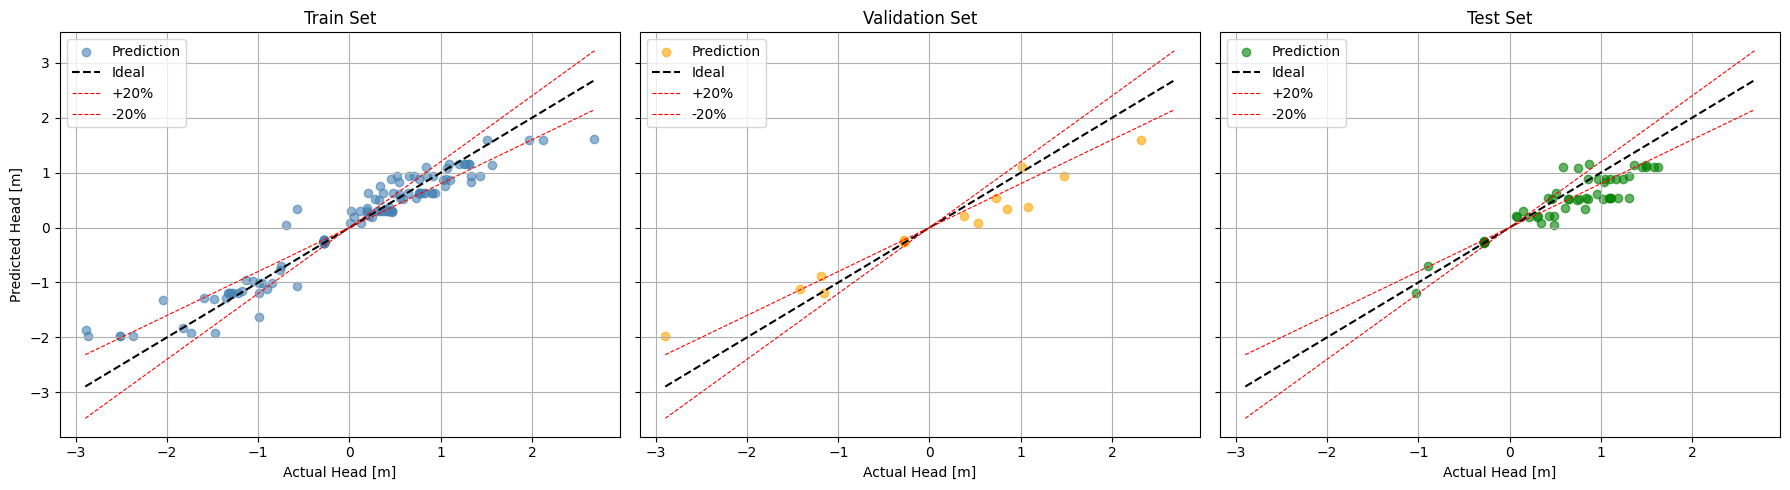

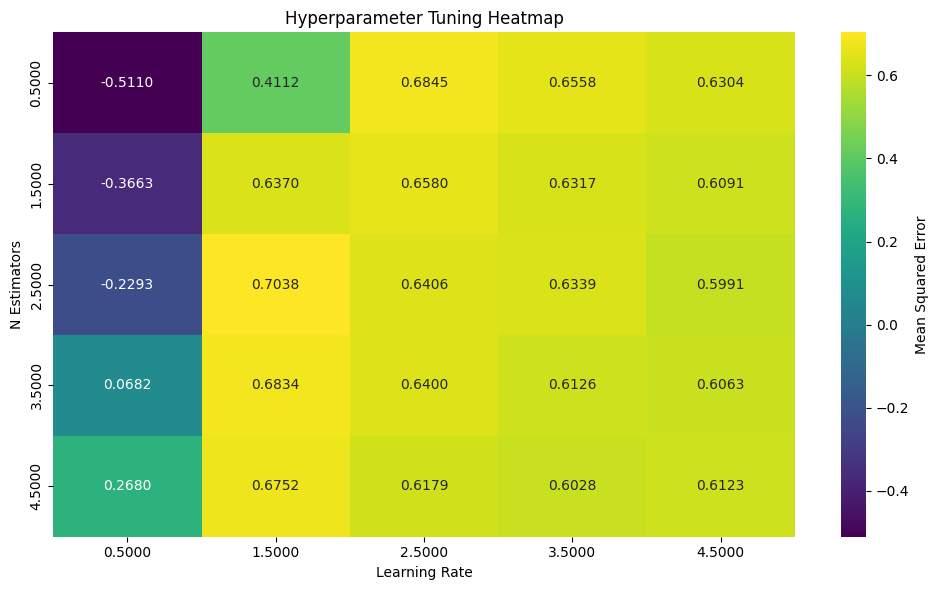

In [68]:
#Train XGBoost new train set (+2 fluids)
xgb_model1, xgb_scores1 = fun.xgboost_with_cv(X_train_scaled1, y_train_scaled1, X_val_scaled1, y_val_scaled1,
                                              X_test_scaled1, y_test_scaled1, param_dist, n_iter, cv_folds, img_name='no')
#Add the model and scores to the list
xgb_modelsGSY.append(xgb_model1)
xgb_scoresGSY.append(xgb_scores1)

**Second Iteration**

In [70]:
#Scaled the candidates pool with the same scaler used for first iteration
X_candidates_scaled2 = scaler_x1.transform(updated_pool1[feature_cols])

/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [72]:
#Select the 2 fluids to simulate
train_sets1 = train_sets[0][feature_cols].copy()
n_selected = 2
fluids_augment, updated_pool2 = fun.greedy_sampling_outputs(xgb_model1, updated_pool1, 
                                                            train_sets1, X_candidates_scaled2, n_selected)
fluids_augment

Selected 2 new candidates:
Remaining pool size: 2996


,rho(kg/m3),k(Pa*s^n),n(-),FluidType,massflow_dim
2960,1004.430686,8.978815,0.345891,PowerLaw,0.05630
2233,1003.645594,9.187962,0.211153,PowerLaw,0.01089


**Data Loading and Preprocesssing**

In [73]:
#Load of the results of the simulations of the selected fluids
file_path = "/Users/danielmorantes/Downloads/DatasetFinal.xlsx"
sheet_name_GSy = 'GSY'
GSy_rawdf = fun.load_excel_data(file_path, sheet_name_GSy) 

 Loaded data with shape: (24, 11)
 Loaded Fluids: 4
Dropped columns: ['Liquid', 'Concentration', 'Flow Rate(GPM)', 'Flow Rate[m3/h]', 'Omega(rpm)']


In [74]:
#BEP scaling of the raw selected fluids
entireGSy, GSy_bepscaled = fun.apply_bep_scaling(GSy_rawdf)
GSy_bepscaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   LiquidNo            15 non-null     int64  
 1   rho(kg/m3)          15 non-null     float64
 2   k(Pa*s^n)           15 non-null     float64
 3   n(-)                15 non-null     float64
 4   massflow_dim        15 non-null     float64
 5   torque_dim          15 non-null     float64
 6   hydraulicpower_dim  15 non-null     float64
 7   breakpower_dim      15 non-null     float64
 8   eff_dim             15 non-null     float64
 9   head_dim            15 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 1.3 KB


In [75]:
#Add to the original train set the GSx generated fluids 2 by 2
train_sets, list_fluids = fun.loop_add_fluids_in_order(bepscaled_initial_trainData, GSy_bepscaled)
train_sets[1] #Look for the Second train set (Original + 4 fluids)

Iteration 1: New training set includes 35 unique fluids
Iteration 2: New training set includes 37 unique fluids


,LiquidNo,rho(kg/m3),k(Pa*s^n),n(-),massflow_dim,torque_dim,hydraulicpower_dim,breakpower_dim,eff_dim,head_dim
0,0,997.000000,0.001000,1.000000,0.000000,0.679632,0.000000,0.679633,0.000000,1.290569
1,0,997.000000,0.001000,1.000000,0.250000,0.724184,0.303160,0.724184,0.418623,1.212641
2,0,997.000000,0.001000,1.000000,0.500000,0.812492,0.582448,0.812492,0.716867,1.164897
3,0,997.000000,0.001000,1.000000,0.750000,0.913659,0.824483,0.913659,0.902397,1.099311
4,0,997.000000,0.001000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...
151,35,1004.430686,8.977882,0.345891,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
152,35,1004.430686,8.977882,0.345891,1.333333,1.000000,1.000000,1.000000,0.951197,0.756015
153,36,1003.645594,9.187962,0.211153,0.333333,1.000000,1.000000,1.000000,0.439000,0.990036
154,36,1003.645594,9.187962,0.211153,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [76]:
#Split and scale new train set
X_train_scaled2, X_val_scaled2, X_test_scaled2, y_train_scaled2, y_val_scaled2, y_test_scaled2, scaler_x2, scaler_y2= fun.splitandscale_byfluid(train_sets[1], testdata_bepscaled,
                                                                                                                                                feature_cols, target_cols, val_size)

Split completed: 140 train samples, 16 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.


Fitting 25 folds for each of 500 candidates, totalling 12500 fits
mse_train: 0.0925
r2_train: 0.9075
mse_val: 0.3354
r2_val: 0.6535
mse_test: 0.0695
r2_test: 0.8205
Best hyperparameters: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.2, 'gamma': 0.2, 'colsample_bytree': 1.0}


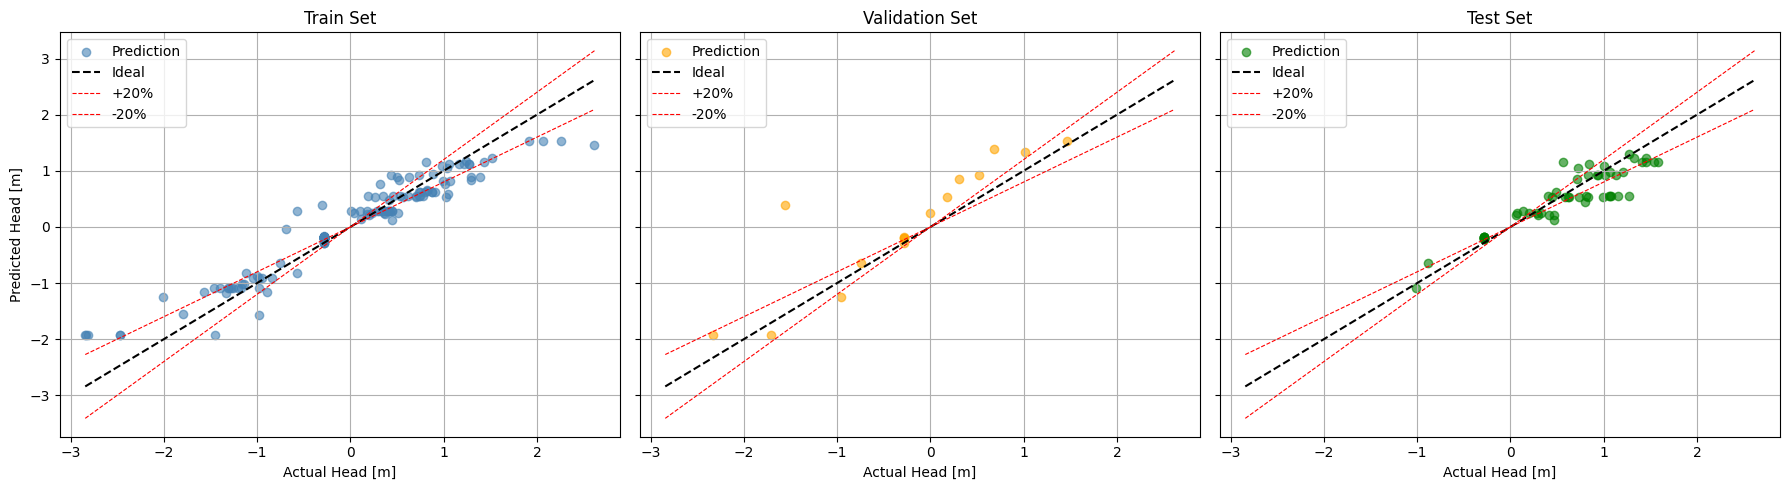

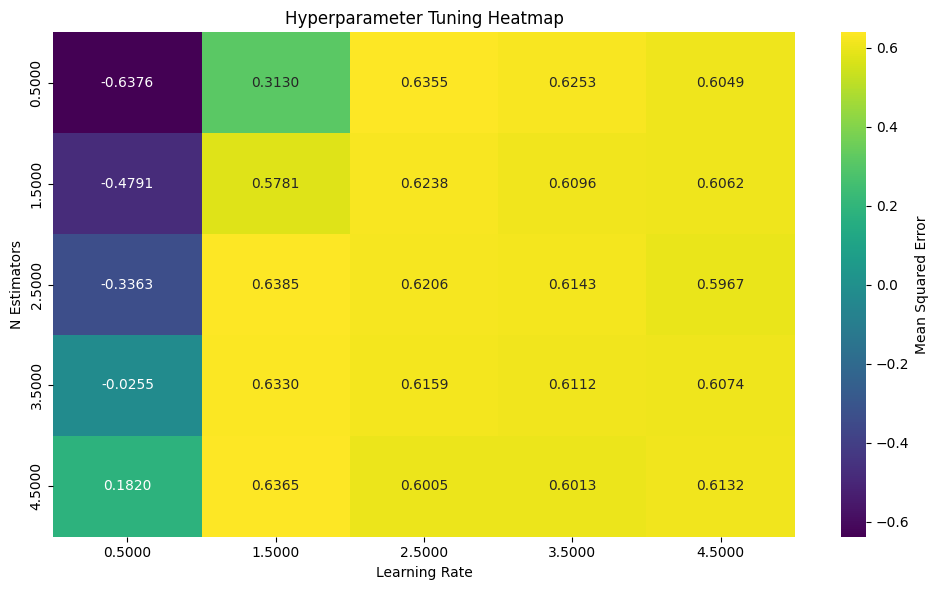

In [ ]:
#Train XGBoost new train set (+4 fluids)
xgb_model2, xgb_scores2 = fun.xgboost_with_cv(X_train_scaled2, y_train_scaled2, X_val_scaled2, y_val_scaled2,
                                              X_test_scaled2, y_test_scaled2, param_dist, n_iter, cv_folds, img_name='no')
#Add the model and scores to the list
xgb_modelsGSY.append(xgb_model2)
xgb_scoresGSY.append(xgb_scores2)

**Third Iteration**

In [ ]:
#Scaled the candidates pool with the same scaler used for second iteration
X_candidates_scaled3 = scaler_x2.transform(updated_pool2[feature_cols])

/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [79]:
#Select the 2 fluids to simulate
train_sets2 = train_sets[1][feature_cols].copy()
n_selected = 2
fluids_augment, updated_pool3 = fun.greedy_sampling_outputs(xgb_model2, updated_pool2, 
                                                            train_sets2, X_candidates_scaled3, n_selected)
fluids_augment

Selected 2 new candidates:
Remaining pool size: 2994


,rho(kg/m3),k(Pa*s^n),n(-),FluidType,massflow_dim
2632,1017.841770,10.993111,0.475363,PowerLaw,0.04136
2615,1014.054486,10.424071,0.409180,PowerLaw,0.09069


**Data Loading and Preprocesssing**

In [80]:
#Load of the results of the simulations of the selected fluids
file_path = "/Users/danielmorantes/Downloads/DatasetFinal.xlsx"
sheet_name_GSy = 'GSY'
GSy_rawdf3 = fun.load_excel_data(file_path, sheet_name_GSy) 

 Loaded data with shape: (36, 11)
 Loaded Fluids: 6
Dropped columns: ['Liquid', 'Concentration', 'Flow Rate(GPM)', 'Flow Rate[m3/h]', 'Omega(rpm)']


In [81]:
#BEP scaling of the raw selected fluids
entireGSy3, GSy_bepscaled3 = fun.apply_bep_scaling(GSy_rawdf3)
GSy_bepscaled3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   LiquidNo            22 non-null     int64  
 1   rho(kg/m3)          22 non-null     float64
 2   k(Pa*s^n)           22 non-null     float64
 3   n(-)                22 non-null     float64
 4   massflow_dim        22 non-null     float64
 5   torque_dim          22 non-null     float64
 6   hydraulicpower_dim  22 non-null     float64
 7   breakpower_dim      22 non-null     float64
 8   eff_dim             22 non-null     float64
 9   head_dim            22 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 1.8 KB


In [82]:
#Add to the original train set the GSx generated fluids 2 by 2
train_sets, list_fluids = fun.loop_add_fluids_in_order(bepscaled_initial_trainData, GSy_bepscaled3)
train_sets[2] #Look for the Third train set (Original + 6 fluids)

Iteration 1: New training set includes 35 unique fluids
Iteration 2: New training set includes 37 unique fluids
Iteration 3: New training set includes 39 unique fluids


,LiquidNo,rho(kg/m3),k(Pa*s^n),n(-),massflow_dim,torque_dim,hydraulicpower_dim,breakpower_dim,eff_dim,head_dim
0,0,997.000000,0.001000,1.000000,0.000000,0.679632,0.000000,0.679633,0.000000,1.290569
1,0,997.000000,0.001000,1.000000,0.250000,0.724184,0.303160,0.724184,0.418623,1.212641
2,0,997.000000,0.001000,1.000000,0.500000,0.812492,0.582448,0.812492,0.716867,1.164897
3,0,997.000000,0.001000,1.000000,0.750000,0.913659,0.824483,0.913659,0.902397,1.099311
4,0,997.000000,0.001000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...
158,37,1017.841770,10.993111,0.475363,1.500000,1.000000,1.000000,1.000000,0.976517,0.721241
159,37,1017.841770,10.993111,0.475363,2.000000,1.000000,1.000000,1.000000,0.581054,0.338567
160,38,1014.054486,10.424071,0.409180,0.333333,1.000000,1.000000,1.000000,0.575302,1.375104
161,38,1014.054486,10.424071,0.409180,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [83]:
#Split and scale new train set
X_train_scaled3, X_val_scaled3, X_test_scaled3, y_train_scaled3, y_val_scaled3, y_test_scaled3, scaler_x3, scaler_y3= fun.splitandscale_byfluid(train_sets[2], testdata_bepscaled,
                                                                                                                                                feature_cols, target_cols, val_size)

Split completed: 143 train samples, 20 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.


Fitting 25 folds for each of 500 candidates, totalling 12500 fits


/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/numpy/ma/core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


mse_train: 0.0445
r2_train: 0.9555
mse_val: 0.0553
r2_val: 0.8897
mse_test: 0.0599
r2_test: 0.8343
Best hyperparameters: {'subsample': 0.8, 'reg_lambda': 0, 'reg_alpha': 0.1, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 1.0}


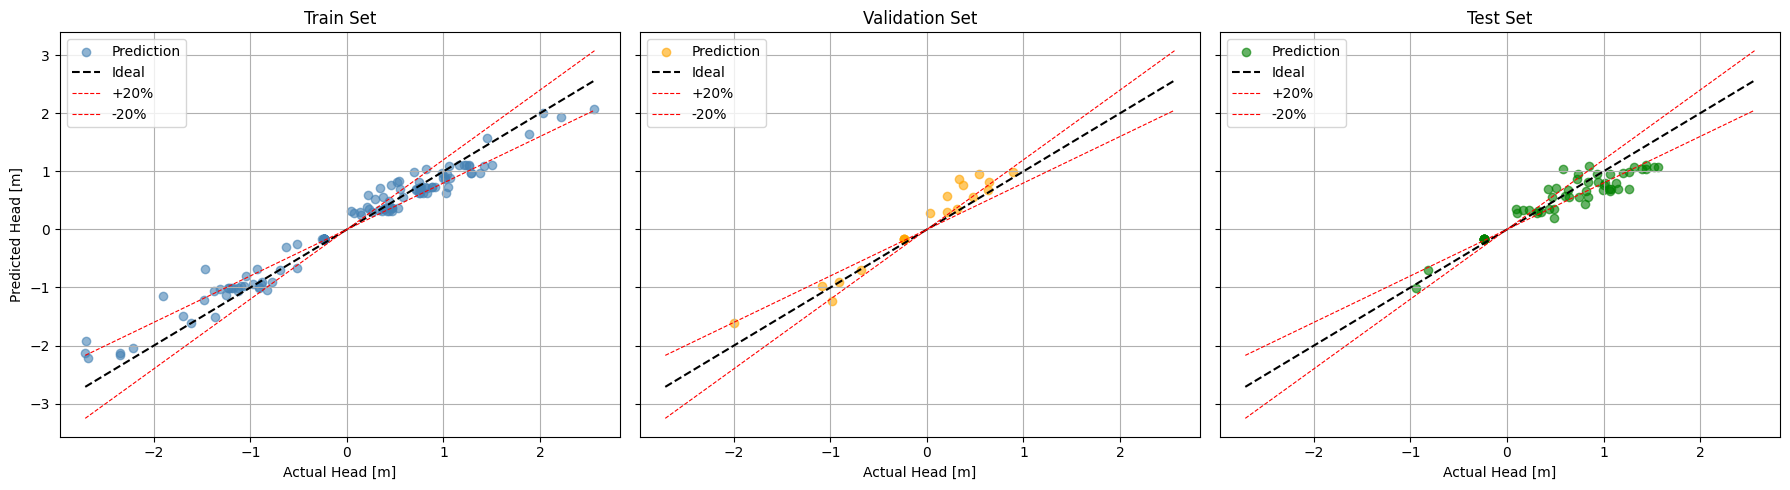

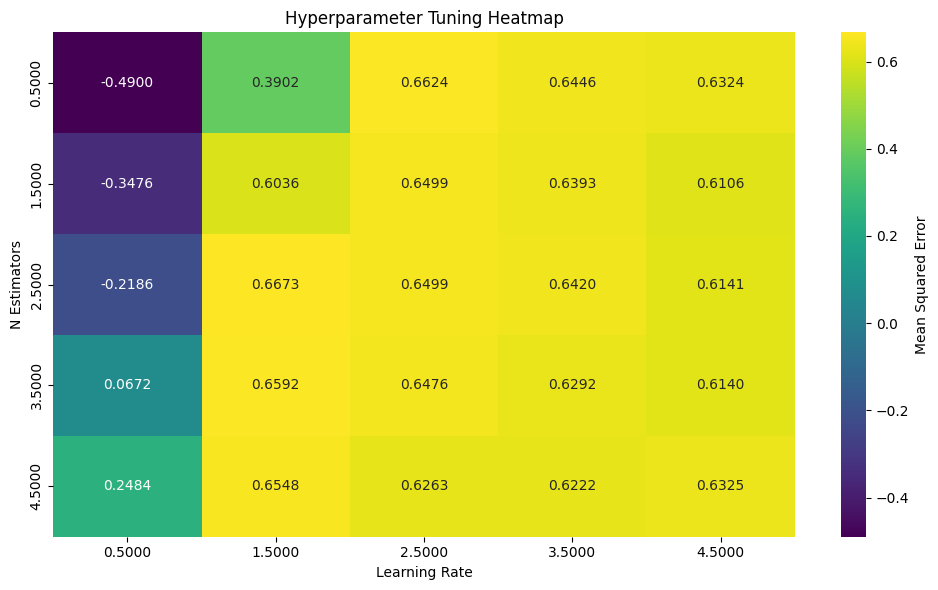

In [84]:
#Train XGBoost new train set (+2 fluids)
xgb_model3, xgb_scores3 = fun.xgboost_with_cv(X_train_scaled3, y_train_scaled3, X_val_scaled3, y_val_scaled3,
                                              X_test_scaled3, y_test_scaled3, param_dist, n_iter, cv_folds, img_name='no')
#Add the model and scores to the list
xgb_modelsGSY.append(xgb_model3)
xgb_scoresGSY.append(xgb_scores3)

**Fourth Iteration**

In [85]:
#Scaled the candidates pool with the same scaler used for third iteration
X_candidates_scaled4 = scaler_x3.transform(updated_pool3[feature_cols])

/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [86]:
#Select the 2 fluids to simulate
train_sets3 = train_sets[2][feature_cols].copy()
n_selected = 2
fluids_augment, updated_pool4 = fun.greedy_sampling_outputs(xgb_model3, updated_pool3, 
                                                            train_sets3, X_candidates_scaled4, n_selected)
fluids_augment

Selected 2 new candidates:
Remaining pool size: 2992


,rho(kg/m3),k(Pa*s^n),n(-),FluidType,massflow_dim
646,830.987782,0.058331,1.0,Newtonian,0.012234
442,876.569602,0.048950,1.0,Newtonian,0.020286


**Data Loading and Preprocesssing**

In [87]:
#Load of the results of the simulations of the selected fluids
file_path = "/Users/danielmorantes/Downloads/DatasetFinal.xlsx"
sheet_name_GSy = 'GSY'
GSy_rawdf4 = fun.load_excel_data(file_path, sheet_name_GSy) 

 Loaded data with shape: (48, 11)
 Loaded Fluids: 8
Dropped columns: ['Liquid', 'Concentration', 'Flow Rate(GPM)', 'Flow Rate[m3/h]', 'Omega(rpm)']


In [88]:
#BEP scaling of the raw selected fluids
entireGSy4, GSy_bepscaled4 = fun.apply_bep_scaling(GSy_rawdf4)
GSy_bepscaled4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   LiquidNo            34 non-null     int64  
 1   rho(kg/m3)          34 non-null     float64
 2   k(Pa*s^n)           34 non-null     float64
 3   n(-)                34 non-null     float64
 4   massflow_dim        34 non-null     float64
 5   torque_dim          34 non-null     float64
 6   hydraulicpower_dim  34 non-null     float64
 7   breakpower_dim      34 non-null     float64
 8   eff_dim             34 non-null     float64
 9   head_dim            34 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 2.8 KB


In [89]:
#Add to the original train set the GSx generated fluids 2 by 2
train_sets, list_fluids = fun.loop_add_fluids_in_order(bepscaled_initial_trainData, GSy_bepscaled4)
train_sets[3] #Look for the Fourth train set (Original + 8 fluids)

Iteration 1: New training set includes 35 unique fluids
Iteration 2: New training set includes 37 unique fluids
Iteration 3: New training set includes 39 unique fluids
Iteration 4: New training set includes 41 unique fluids


,LiquidNo,rho(kg/m3),k(Pa*s^n),n(-),massflow_dim,torque_dim,hydraulicpower_dim,breakpower_dim,eff_dim,head_dim
0,0,997.000000,0.00100,1.0,0.000000,0.679632,0.000000,0.679633,0.000000,1.290569
1,0,997.000000,0.00100,1.0,0.250000,0.724184,0.303160,0.724184,0.418623,1.212641
2,0,997.000000,0.00100,1.0,0.500000,0.812492,0.582448,0.812492,0.716867,1.164897
3,0,997.000000,0.00100,1.0,0.750000,0.913659,0.824483,0.913659,0.902397,1.099311
4,0,997.000000,0.00100,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...
170,40,876.569602,0.04895,1.0,0.019564,1.000000,1.000000,1.000000,0.042162,1.575370
171,40,876.569602,0.04895,1.0,0.333333,1.000000,1.000000,1.000000,0.597876,1.449534
172,40,876.569602,0.04895,1.0,0.666667,1.000000,1.000000,1.000000,0.943934,1.285259
173,40,876.569602,0.04895,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [90]:
#Split and scale new train set
X_train_scaled4, X_val_scaled4, X_test_scaled4, y_train_scaled4, y_val_scaled4, y_test_scaled4, scaler_x4, scaler_y4= fun.splitandscale_byfluid(train_sets[3], testdata_bepscaled,
                                                                                                                                                feature_cols, target_cols, val_size)

Split completed: 152 train samples, 23 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.


Fitting 25 folds for each of 500 candidates, totalling 12500 fits
mse_train: 0.0170
r2_train: 0.9830
mse_val: 0.1321
r2_val: 0.8929
mse_test: 0.1175
r2_test: 0.6979
Best hyperparameters: {'subsample': 0.8, 'reg_lambda': 0, 'reg_alpha': 0.1, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}


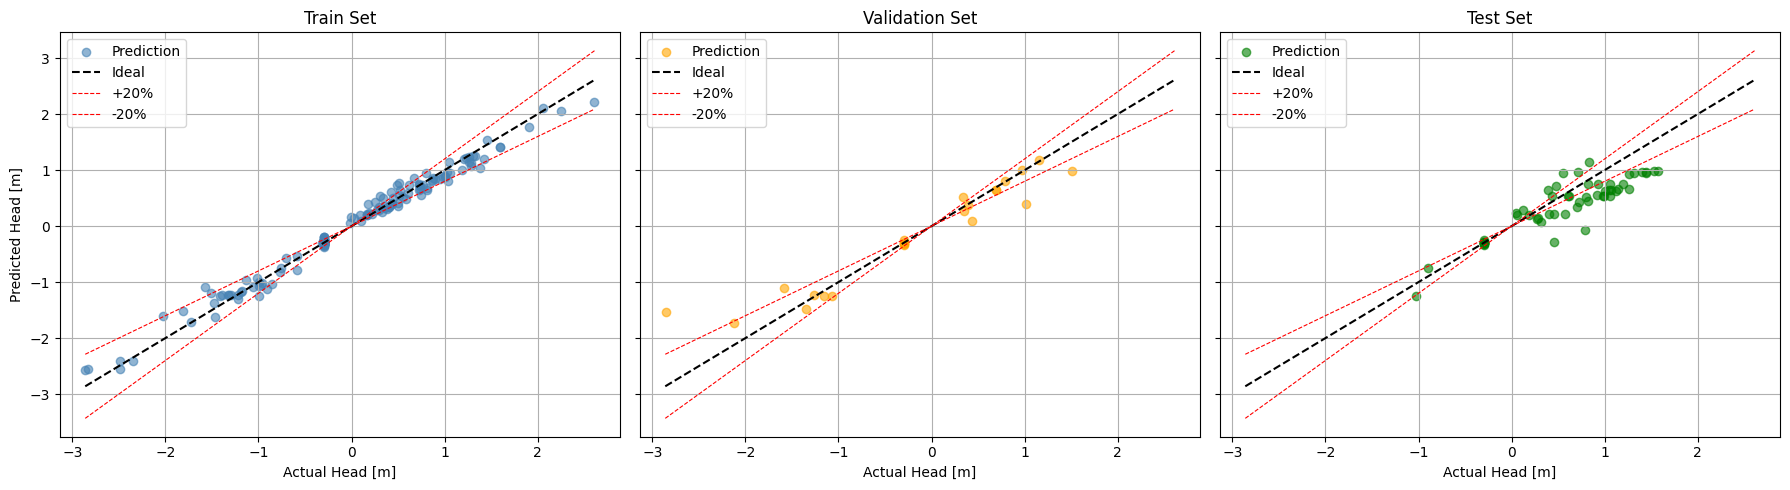

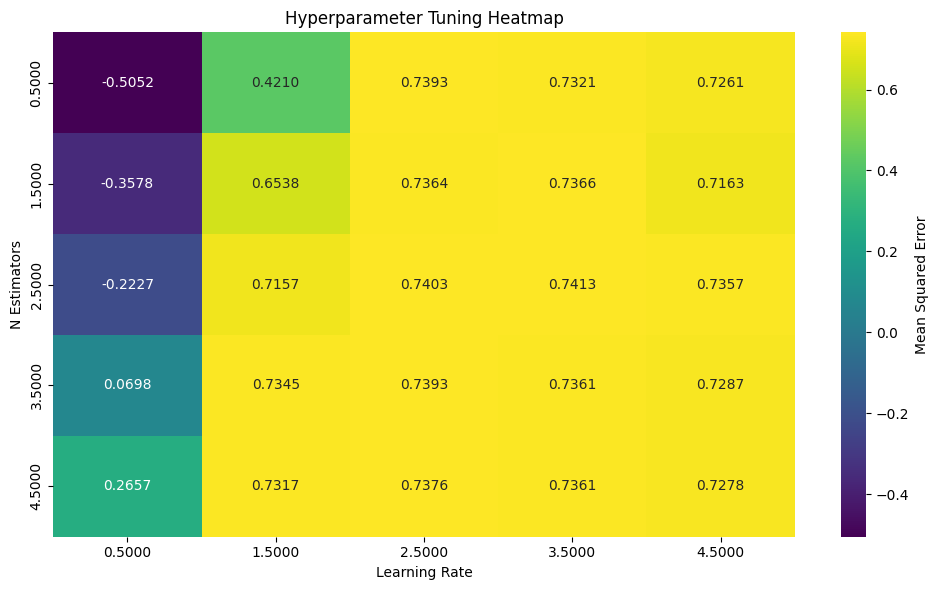

In [91]:
#Train XGBoost new train set (+2 fluids)
xgb_model4, xgb_scores4 = fun.xgboost_with_cv(X_train_scaled4, y_train_scaled4, X_val_scaled4, y_val_scaled4,
                                              X_test_scaled4, y_test_scaled4, param_dist, n_iter, cv_folds, img_name='no')
#Add the model and scores to the list
xgb_modelsGSY.append(xgb_model4)
xgb_scoresGSY.append(xgb_scores4)

**Fifth Iteration**

In [92]:
#Scaled the candidates pool with the same scaler used for fourth iteration
X_candidates_scaled5 = scaler_x4.transform(updated_pool4[feature_cols])

/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [95]:
#Select the 2 fluids to simulate
train_sets4 = train_sets[3][feature_cols].copy()
n_selected = 2
fluids_augment, updated_pool5 = fun.greedy_sampling_outputs(xgb_model4, updated_pool4, 
                                                            X_train_scaled4, X_candidates_scaled4, n_selected)
fluids_augment

Selected 2 new candidates:
Remaining pool size: 2990


,rho(kg/m3),k(Pa*s^n),n(-),FluidType,massflow_dim
2735,1003.573792,5.866280,0.214531,PowerLaw,0.017835
2108,1012.254793,9.758737,0.362441,PowerLaw,0.175464


**Data Loading and Preprocesssing**

In [96]:
#Load of the results of the simulations of the selected fluids
file_path = "/Users/danielmorantes/Downloads/DatasetFinal.xlsx"
sheet_name_GSy = 'GSY'
GSy_rawdf5 = fun.load_excel_data(file_path, sheet_name_GSy) 

 Loaded data with shape: (60, 11)
 Loaded Fluids: 10
Dropped columns: ['Liquid', 'Concentration', 'Flow Rate(GPM)', 'Flow Rate[m3/h]', 'Omega(rpm)']


In [97]:
#BEP scaling of the raw selected fluids
entireGSy5, GSy_bepscaled5 = fun.apply_bep_scaling(GSy_rawdf5)
GSy_bepscaled5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   LiquidNo            41 non-null     int64  
 1   rho(kg/m3)          41 non-null     float64
 2   k(Pa*s^n)           41 non-null     float64
 3   n(-)                41 non-null     float64
 4   massflow_dim        41 non-null     float64
 5   torque_dim          41 non-null     float64
 6   hydraulicpower_dim  41 non-null     float64
 7   breakpower_dim      41 non-null     float64
 8   eff_dim             41 non-null     float64
 9   head_dim            41 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 3.3 KB


In [98]:
#Add to the original train set the GSx generated fluids 2 by 2
train_sets, list_fluids = fun.loop_add_fluids_in_order(bepscaled_initial_trainData, GSy_bepscaled5)
train_sets[4] #Look for the Fifth train set (Original + 10 fluids)

Iteration 1: New training set includes 35 unique fluids
Iteration 2: New training set includes 37 unique fluids
Iteration 3: New training set includes 39 unique fluids
Iteration 4: New training set includes 41 unique fluids
Iteration 5: New training set includes 43 unique fluids


,LiquidNo,rho(kg/m3),k(Pa*s^n),n(-),massflow_dim,torque_dim,hydraulicpower_dim,breakpower_dim,eff_dim,head_dim
0,0,997.000000,0.001000,1.000000,0.000000,0.679632,0.000000,0.679633,0.000000,1.290569
1,0,997.000000,0.001000,1.000000,0.250000,0.724184,0.303160,0.724184,0.418623,1.212641
2,0,997.000000,0.001000,1.000000,0.500000,0.812492,0.582448,0.812492,0.716867,1.164897
3,0,997.000000,0.001000,1.000000,0.750000,0.913659,0.824483,0.913659,0.902397,1.099311
4,0,997.000000,0.001000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...
177,42,1012.254793,9.758737,0.362441,0.216641,1.000000,1.000000,1.000000,0.368264,1.387192
178,42,1012.254793,9.758737,0.362441,0.492817,1.000000,1.000000,1.000000,0.691183,1.231972
179,42,1012.254793,9.758737,0.362441,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
180,42,1012.254793,9.758737,0.362441,1.478450,1.000000,1.000000,1.000000,0.936072,0.673380


In [99]:
#Split and scale new train set
X_train_scaled5, X_val_scaled5, X_test_scaled5, y_train_scaled5, y_val_scaled5, y_test_scaled5, scaler_x5, scaler_y5= fun.splitandscale_byfluid(train_sets[4], testdata_bepscaled,
                                                                                                                                                feature_cols, target_cols, val_size)

Split completed: 160 train samples, 22 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.


Fitting 25 folds for each of 500 candidates, totalling 12500 fits


/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/numpy/ma/core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


mse_train: 0.0447
r2_train: 0.9553
mse_val: 0.1616
r2_val: 0.8564
mse_test: 0.1323
r2_test: 0.6519
Best hyperparameters: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 700, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 0.6}


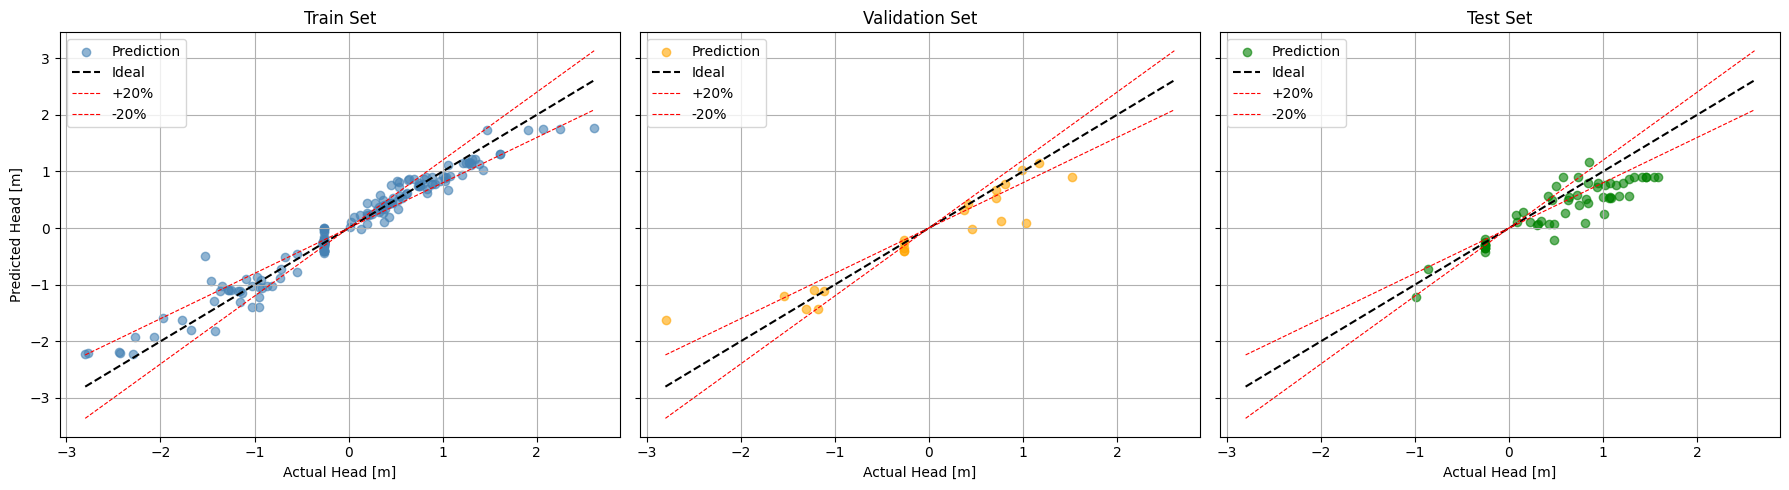

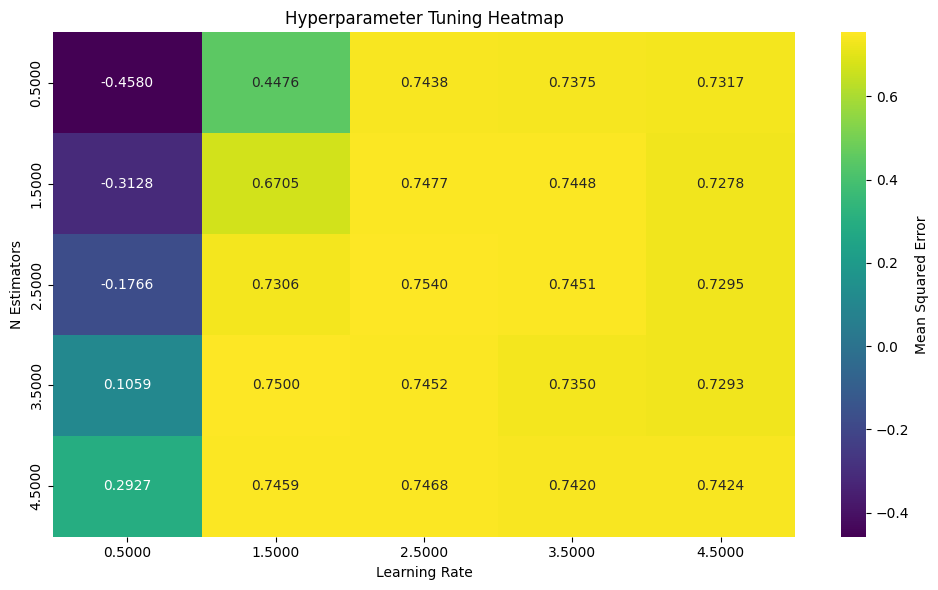

In [101]:
#Train XGBoost new train set (+2 fluids)
xgb_model5, xgb_scores5 = fun.xgboost_with_cv(X_train_scaled5, y_train_scaled5, X_val_scaled5, y_val_scaled5,
                                              X_test_scaled5, y_test_scaled5, param_dist, n_iter, cv_folds, img_name='no')
#Add the model and scores to the list
xgb_modelsGSY.append(xgb_model5)
xgb_scoresGSY.append(xgb_scores5)

**Sixth Iteration**


In [102]:
#Scaled the candidates pool with the same scaler used for fifth iteration
X_candidates_scaled6 = scaler_x5.transform(updated_pool5[feature_cols])

/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [103]:
#Select the 2 fluids to simulate
train_sets5 = train_sets[4][feature_cols].copy()
n_selected = 2
fluids_augment, updated_pool6 = fun.greedy_sampling_outputs(xgb_model5, updated_pool5, 
                                                            X_train_scaled5, X_candidates_scaled5, n_selected)
fluids_augment

Selected 2 new candidates:
Remaining pool size: 2988


,rho(kg/m3),k(Pa*s^n),n(-),FluidType,massflow_dim
2002,1012.533278,0.066456,0.394110,PowerLaw,0.014255
2535,1014.780526,0.720781,0.277604,PowerLaw,0.657646


**Data Loading and Preprocesssing**

In [104]:
#Load of the results of the simulations of the selected fluids
file_path = "/Users/danielmorantes/Downloads/DatasetFinal.xlsx"
sheet_name_GSy = 'GSY'
GSy_rawdf6 = fun.load_excel_data(file_path, sheet_name_GSy) 

 Loaded data with shape: (72, 11)
 Loaded Fluids: 12
Dropped columns: ['Liquid', 'Concentration', 'Flow Rate(GPM)', 'Flow Rate[m3/h]', 'Omega(rpm)']


In [105]:
#BEP scaling of the raw selected fluids
entireGSy6, GSy_bepscaled6 = fun.apply_bep_scaling(GSy_rawdf6)
GSy_bepscaled6.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   LiquidNo            46 non-null     int64  
 1   rho(kg/m3)          46 non-null     float64
 2   k(Pa*s^n)           46 non-null     float64
 3   n(-)                46 non-null     float64
 4   massflow_dim        46 non-null     float64
 5   torque_dim          46 non-null     float64
 6   hydraulicpower_dim  46 non-null     float64
 7   breakpower_dim      46 non-null     float64
 8   eff_dim             46 non-null     float64
 9   head_dim            46 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 3.7 KB


In [106]:
#Add to the original train set the GSx generated fluids 2 by 2
train_sets, list_fluids = fun.loop_add_fluids_in_order(bepscaled_initial_trainData, GSy_bepscaled6)
train_sets[5] #Look for the Sixth train set (Original + 12 fluids)

Iteration 1: New training set includes 35 unique fluids
Iteration 2: New training set includes 37 unique fluids
Iteration 3: New training set includes 39 unique fluids
Iteration 4: New training set includes 41 unique fluids
Iteration 5: New training set includes 43 unique fluids
Iteration 6: New training set includes 45 unique fluids


,LiquidNo,rho(kg/m3),k(Pa*s^n),n(-),massflow_dim,torque_dim,hydraulicpower_dim,breakpower_dim,eff_dim,head_dim
0,0,997.000000,0.001000,1.000000,0.000000,0.679632,0.000000,0.679633,0.000000,1.290569
1,0,997.000000,0.001000,1.000000,0.250000,0.724184,0.303160,0.724184,0.418623,1.212641
2,0,997.000000,0.001000,1.000000,0.500000,0.812492,0.582448,0.812492,0.716867,1.164897
3,0,997.000000,0.001000,1.000000,0.750000,0.913659,0.824483,0.913659,0.902397,1.099311
4,0,997.000000,0.001000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...
182,43,1012.533278,0.066456,0.394110,0.500000,1.000000,1.000000,1.000000,0.307756,0.465308
183,43,1012.533278,0.066456,0.394110,0.750000,1.000000,1.000000,1.000000,0.959840,1.166912
184,43,1012.533278,0.066456,0.394110,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
185,44,1014.780526,0.720781,0.277604,0.666667,1.000000,1.000000,1.000000,0.811481,1.093943


In [107]:
#Split and scale new train set
X_train_scaled6, X_val_scaled6, X_test_scaled6, y_train_scaled6, y_val_scaled6, y_test_scaled6, scaler_x6, scaler_y6= fun.splitandscale_byfluid(train_sets[5], testdata_bepscaled,
                                                                                                                                                feature_cols, target_cols, val_size)

Split completed: 166 train samples, 21 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.


Fitting 25 folds for each of 500 candidates, totalling 12500 fits
mse_train: 0.0877
r2_train: 0.9123
mse_val: 0.0296
r2_val: 0.9630
mse_test: 0.0903
r2_test: 0.7557
Best hyperparameters: {'subsample': 1.0, 'reg_lambda': 0, 'reg_alpha': 1, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.2, 'gamma': 0.2, 'colsample_bytree': 1.0}


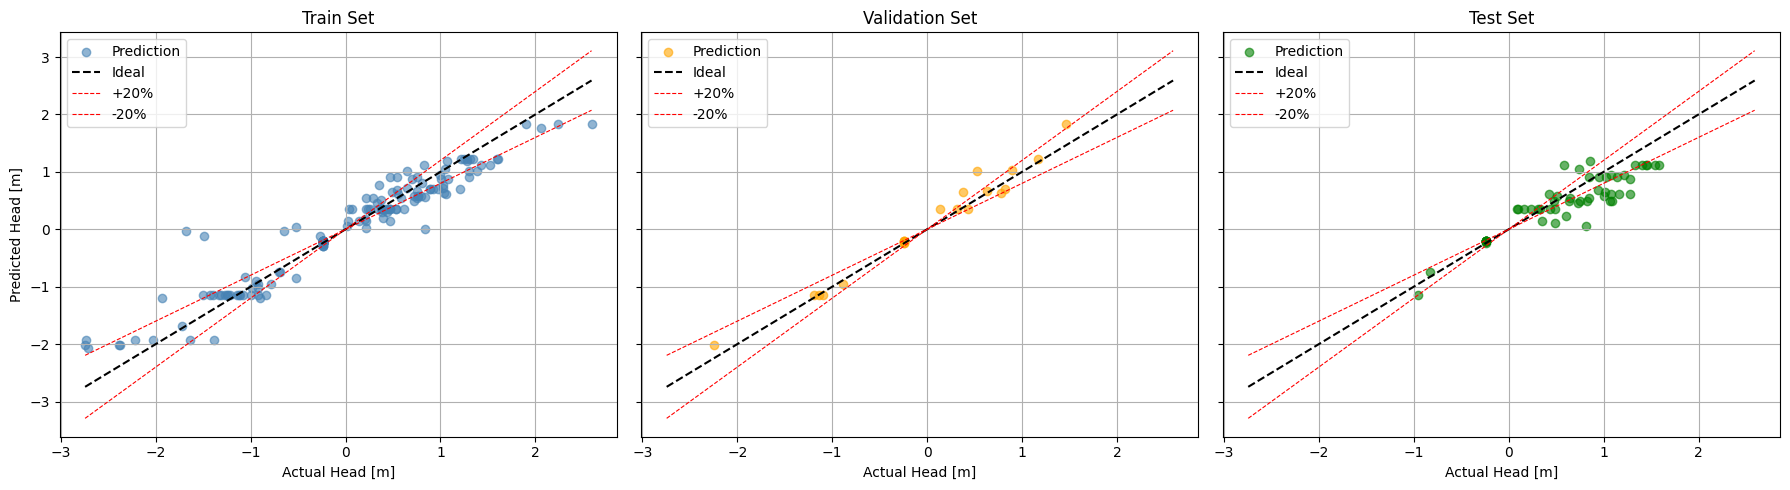

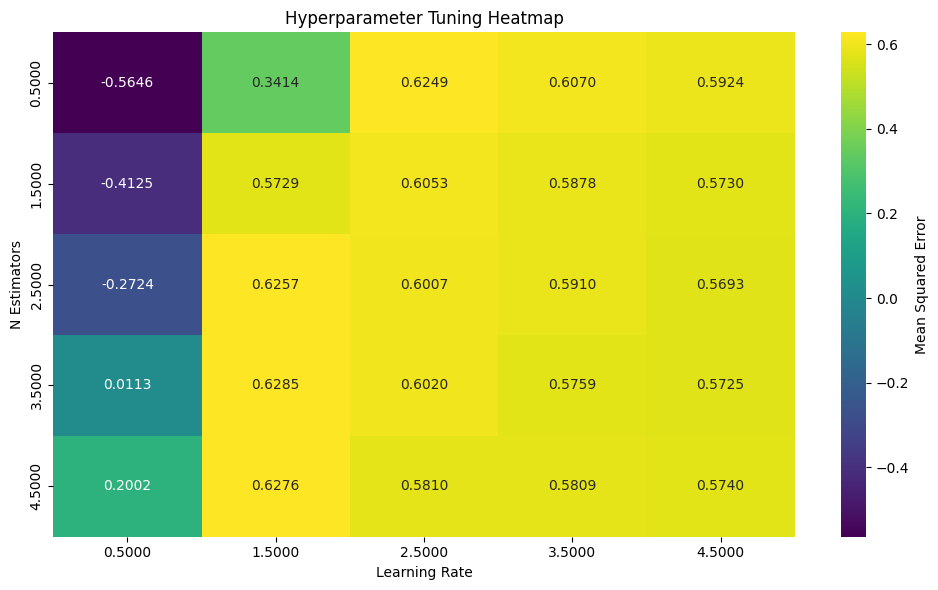

In [108]:
#Train XGBoost new train set (+2 fluids)
xgb_model6, xgb_scores6 = fun.xgboost_with_cv(X_train_scaled6, y_train_scaled6, X_val_scaled6, y_val_scaled6,
                                              X_test_scaled6, y_test_scaled6, param_dist, n_iter, cv_folds, img_name='no')
#Add the model and scores to the list
xgb_modelsGSY.append(xgb_model6)
xgb_scoresGSY.append(xgb_scores6)

**Seventh Iteration**

In [109]:
#Scaled the candidates pool with the same scaler used for sixth iteration
X_candidates_scaled7 = scaler_x6.transform(updated_pool6[feature_cols])

/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [110]:
#Select the 2 fluids to simulate
train_sets6 = train_sets[5][feature_cols].copy()
n_selected = 2
fluids_augment, updated_pool7 = fun.greedy_sampling_outputs(xgb_model6, updated_pool6, 
                                                            X_test_scaled6, X_candidates_scaled6, n_selected)
fluids_augment

Selected 2 new candidates:
Remaining pool size: 2986


,rho(kg/m3),k(Pa*s^n),n(-),FluidType,massflow_dim
2574,1014.208645,5.914221,0.523915,PowerLaw,0.147278
2607,1007.889718,10.874080,0.374017,PowerLaw,1.175148


**Data Loading and Preprocesssing**

In [111]:
#Load of the results of the simulations of the selected fluids
file_path = "/Users/danielmorantes/Downloads/DatasetFinal.xlsx"
sheet_name_GSy = 'GSY'
GSy_rawdf7 = fun.load_excel_data(file_path, sheet_name_GSy) 

 Loaded data with shape: (84, 11)
 Loaded Fluids: 14
Dropped columns: ['Liquid', 'Concentration', 'Flow Rate(GPM)', 'Flow Rate[m3/h]', 'Omega(rpm)']


In [112]:
#BEP scaling of the raw selected fluids
entireGSy7, GSy_bepscaled7 = fun.apply_bep_scaling(GSy_rawdf7)
GSy_bepscaled7.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   LiquidNo            57 non-null     int64  
 1   rho(kg/m3)          57 non-null     float64
 2   k(Pa*s^n)           57 non-null     float64
 3   n(-)                57 non-null     float64
 4   massflow_dim        57 non-null     float64
 5   torque_dim          57 non-null     float64
 6   hydraulicpower_dim  57 non-null     float64
 7   breakpower_dim      57 non-null     float64
 8   eff_dim             57 non-null     float64
 9   head_dim            57 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 4.6 KB


In [113]:
#Add to the original train set the GSx generated fluids 2 by 2
train_sets, list_fluids = fun.loop_add_fluids_in_order(bepscaled_initial_trainData, GSy_bepscaled7)
train_sets[6] #Look for the Seventh train set (Original + 14 fluids)

Iteration 1: New training set includes 35 unique fluids
Iteration 2: New training set includes 37 unique fluids
Iteration 3: New training set includes 39 unique fluids
Iteration 4: New training set includes 41 unique fluids
Iteration 5: New training set includes 43 unique fluids
Iteration 6: New training set includes 45 unique fluids
Iteration 7: New training set includes 47 unique fluids


,LiquidNo,rho(kg/m3),k(Pa*s^n),n(-),massflow_dim,torque_dim,hydraulicpower_dim,breakpower_dim,eff_dim,head_dim
0,0,997.000000,0.00100,1.000000,0.000000,0.679632,0.000000,0.679633,0.000000,1.290569
1,0,997.000000,0.00100,1.000000,0.250000,0.724184,0.303160,0.724184,0.418623,1.212641
2,0,997.000000,0.00100,1.000000,0.500000,0.812492,0.582448,0.812492,0.716867,1.164897
3,0,997.000000,0.00100,1.000000,0.750000,0.913659,0.824483,0.913659,0.902397,1.099311
4,0,997.000000,0.00100,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...
193,46,1007.889718,10.87408,0.374017,0.333333,1.000000,1.000000,1.000000,0.166708,0.474708
194,46,1007.889718,10.87408,0.374017,0.666667,1.000000,1.000000,1.000000,0.490513,0.596178
195,46,1007.889718,10.87408,0.374017,0.985636,1.000000,1.000000,1.000000,0.995539,1.003135
196,46,1007.889718,10.87408,0.374017,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [114]:
#Split and scale new train set
X_train_scaled7, X_val_scaled7, X_test_scaled7, y_train_scaled7, y_val_scaled7, y_test_scaled7, scaler_x7, scaler_y7= fun.splitandscale_byfluid(train_sets[6], testdata_bepscaled,
                                                                                                                                                feature_cols, target_cols, val_size)

Split completed: 174 train samples, 24 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.


Fitting 25 folds for each of 500 candidates, totalling 12500 fits


/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/numpy/ma/core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


mse_train: 0.0990
r2_train: 0.9010
mse_val: 0.2565
r2_val: 0.6567
mse_test: 0.0605
r2_test: 0.8336
Best hyperparameters: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0.5, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.2, 'gamma': 0.2, 'colsample_bytree': 1.0}


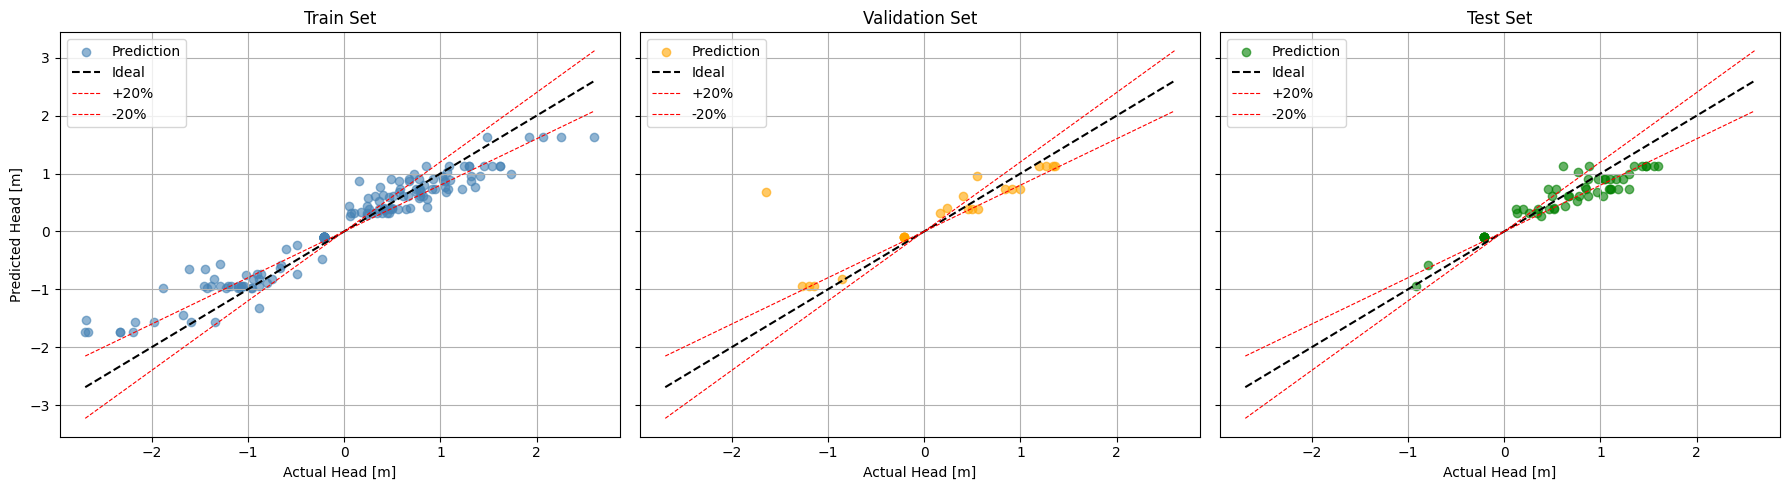

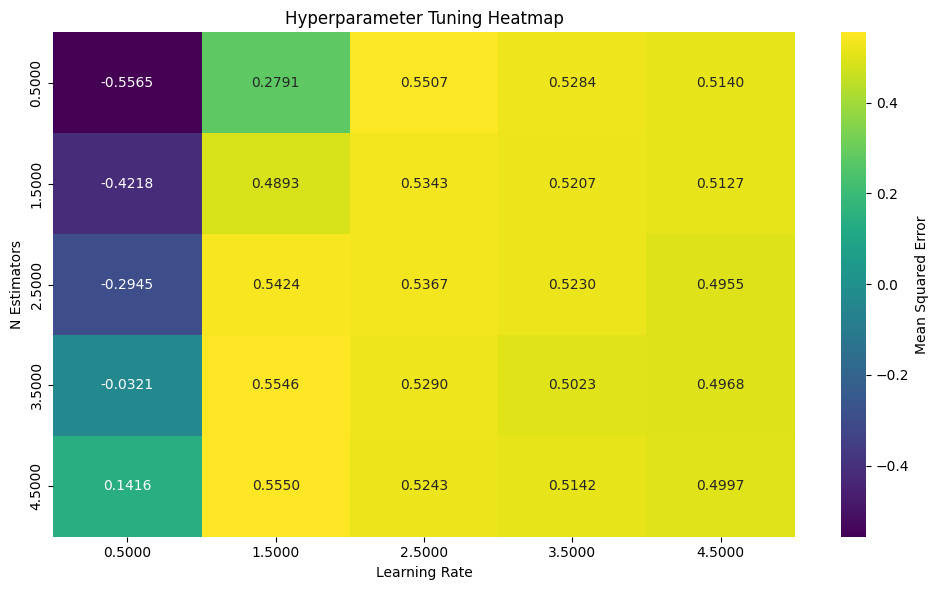

In [115]:
#Train XGBoost new train set (+2 fluids)
xgb_model7, xgb_scores7 = fun.xgboost_with_cv(X_train_scaled7, y_train_scaled7, X_val_scaled7, y_val_scaled7,
                                              X_test_scaled7, y_test_scaled7, param_dist, n_iter, cv_folds, img_name='no')
#Add the model and scores to the list
xgb_modelsGSY.append(xgb_model7)
xgb_scoresGSY.append(xgb_scores7)

**Eigth Iteration**

In [116]:
#Scaled the candidates pool with the same scaler used for seventh iteration
X_candidates_scaled8 = scaler_x7.transform(updated_pool7[feature_cols])

/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [118]:
#Select the 2 fluids to simulate
train_sets7 = train_sets[6][feature_cols].copy()
n_selected = 2
fluids_augment, updated_pool8 = fun.greedy_sampling_outputs(xgb_model7, updated_pool7, 
                                                            X_train_scaled7, X_candidates_scaled7, n_selected)
fluids_augment

Selected 2 new candidates:
Remaining pool size: 2984


,rho(kg/m3),k(Pa*s^n),n(-),FluidType,massflow_dim
2780,1006.395253,2.818776,0.551725,PowerLaw,0.079456
2640,1008.626581,9.144737,0.400024,PowerLaw,0.743788


**Data Loading and Preprocesssing**

In [119]:
#Load of the results of the simulations of the selected fluids
file_path = "/Users/danielmorantes/Downloads/DatasetFinal.xlsx"
sheet_name_GSy = 'GSY'
GSy_rawdf8 = fun.load_excel_data(file_path, sheet_name_GSy) 

 Loaded data with shape: (96, 11)
 Loaded Fluids: 16
Dropped columns: ['Liquid', 'Concentration', 'Flow Rate(GPM)', 'Flow Rate[m3/h]', 'Omega(rpm)']


In [120]:
#BEP scaling of the raw selected fluids
entireGSy8, GSy_bepscaled8 = fun.apply_bep_scaling(GSy_rawdf8)
GSy_bepscaled8.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   LiquidNo            65 non-null     int64  
 1   rho(kg/m3)          65 non-null     float64
 2   k(Pa*s^n)           65 non-null     float64
 3   n(-)                65 non-null     float64
 4   massflow_dim        65 non-null     float64
 5   torque_dim          65 non-null     float64
 6   hydraulicpower_dim  65 non-null     float64
 7   breakpower_dim      65 non-null     float64
 8   eff_dim             65 non-null     float64
 9   head_dim            65 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 5.2 KB


In [121]:
#Add to the original train set the GSx generated fluids 2 by 2
train_sets, list_fluids = fun.loop_add_fluids_in_order(bepscaled_initial_trainData, GSy_bepscaled8)
train_sets[7] #Look for the Eigth train set (Original + 16 fluids)

Iteration 1: New training set includes 35 unique fluids
Iteration 2: New training set includes 37 unique fluids
Iteration 3: New training set includes 39 unique fluids
Iteration 4: New training set includes 41 unique fluids
Iteration 5: New training set includes 43 unique fluids
Iteration 6: New training set includes 45 unique fluids
Iteration 7: New training set includes 47 unique fluids
Iteration 8: New training set includes 49 unique fluids


,LiquidNo,rho(kg/m3),k(Pa*s^n),n(-),massflow_dim,torque_dim,hydraulicpower_dim,breakpower_dim,eff_dim,head_dim
0,0,997.000000,0.001000,1.000000,0.000000,0.679632,0.000000,0.679633,0.000000,1.290569
1,0,997.000000,0.001000,1.000000,0.250000,0.724184,0.303160,0.724184,0.418623,1.212641
2,0,997.000000,0.001000,1.000000,0.500000,0.812492,0.582448,0.812492,0.716867,1.164897
3,0,997.000000,0.001000,1.000000,0.750000,0.913659,0.824483,0.913659,0.902397,1.099311
4,0,997.000000,0.001000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...
201,47,1006.395253,2.818776,0.551725,1.333333,1.000000,1.000000,1.000000,0.836327,0.661528
202,48,1008.626581,9.144737,0.400024,0.333333,1.000000,1.000000,1.000000,0.558465,1.339186
203,48,1008.626581,9.144737,0.400024,0.666667,1.000000,1.000000,1.000000,0.850572,1.129113
204,48,1008.626581,9.144737,0.400024,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [122]:
#Split and scale new train set
X_train_scaled8, X_val_scaled8, X_test_scaled8, y_train_scaled8, y_val_scaled8, y_test_scaled8, scaler_x8, scaler_y8= fun.splitandscale_byfluid(train_sets[7], testdata_bepscaled,
                                                                                                                                                feature_cols, target_cols, val_size)

Split completed: 181 train samples, 25 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.


Fitting 25 folds for each of 500 candidates, totalling 12500 fits
mse_train: 0.1185
r2_train: 0.8815
mse_val: 0.0622
r2_val: 0.9304
mse_test: 0.0826
r2_test: 0.7760
Best hyperparameters: {'subsample': 1.0, 'reg_lambda': 10, 'reg_alpha': 0.1, 'n_estimators': 700, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}


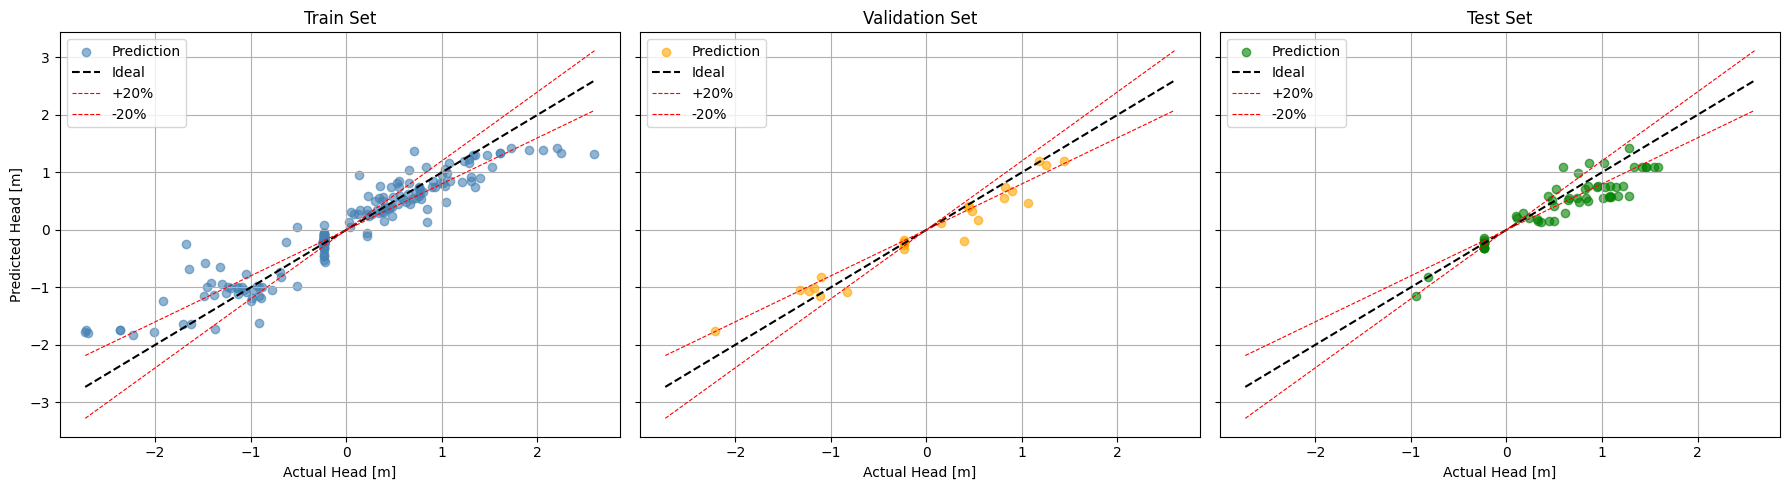

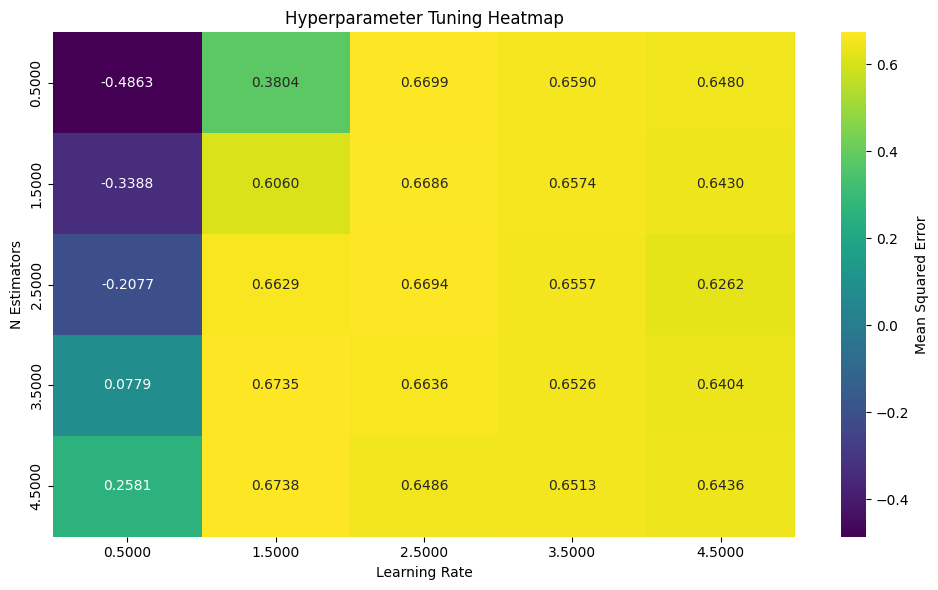

In [123]:
#Train XGBoost new train set (+2 fluids)
xgb_model8, xgb_scores8 = fun.xgboost_with_cv(X_train_scaled8, y_train_scaled8, X_val_scaled8, y_val_scaled8,
                                              X_test_scaled8, y_test_scaled8, param_dist, n_iter, cv_folds, img_name='no')
#Add the model and scores to the list
xgb_modelsGSY.append(xgb_model8)
xgb_scoresGSY.append(xgb_scores8)

**Nineth Iteration**

In [124]:
#Scaled the candidates pool with the same scaler used for eight iteration
X_candidates_scaled9 = scaler_x8.transform(updated_pool8[feature_cols])

/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [125]:
#Select the 2 fluids to simulate
train_sets8 = train_sets[7][feature_cols].copy()
n_selected = 2
fluids_augment, updated_pool9 = fun.greedy_sampling_outputs(xgb_model8, updated_pool8, 
                                                            X_train_scaled8, X_candidates_scaled8, n_selected)
fluids_augment

Selected 2 new candidates:
Remaining pool size: 2982


,rho(kg/m3),k(Pa*s^n),n(-),FluidType,massflow_dim
2562,1015.475979,10.570406,0.434511,PowerLaw,1.318255
2727,1013.626842,10.579249,0.568023,PowerLaw,0.490331


**Data Loading and Preprocesssing**

In [126]:
#Load of the results of the simulations of the selected fluids
file_path = "/Users/danielmorantes/Downloads/DatasetFinal.xlsx"
sheet_name_GSy = 'GSY'
GSy_rawdf9 = fun.load_excel_data(file_path, sheet_name_GSy) 

 Loaded data with shape: (108, 11)
 Loaded Fluids: 18
Dropped columns: ['Liquid', 'Concentration', 'Flow Rate(GPM)', 'Flow Rate[m3/h]', 'Omega(rpm)']


In [127]:
#BEP scaling of the raw selected fluids
entireGSy9, GSy_bepscaled9 = fun.apply_bep_scaling(GSy_rawdf9)
GSy_bepscaled9.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   LiquidNo            73 non-null     int64  
 1   rho(kg/m3)          73 non-null     float64
 2   k(Pa*s^n)           73 non-null     float64
 3   n(-)                73 non-null     float64
 4   massflow_dim        73 non-null     float64
 5   torque_dim          73 non-null     float64
 6   hydraulicpower_dim  73 non-null     float64
 7   breakpower_dim      73 non-null     float64
 8   eff_dim             73 non-null     float64
 9   head_dim            73 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 5.8 KB


In [128]:
#Add to the original train set the GSx generated fluids 2 by 2
train_sets, list_fluids = fun.loop_add_fluids_in_order(bepscaled_initial_trainData, GSy_bepscaled9)
train_sets[8] #Look for the Nineth train set (Original + 18 fluids)

Iteration 1: New training set includes 35 unique fluids
Iteration 2: New training set includes 37 unique fluids
Iteration 3: New training set includes 39 unique fluids
Iteration 4: New training set includes 41 unique fluids
Iteration 5: New training set includes 43 unique fluids
Iteration 6: New training set includes 45 unique fluids
Iteration 7: New training set includes 47 unique fluids
Iteration 8: New training set includes 49 unique fluids
Iteration 9: New training set includes 51 unique fluids


,LiquidNo,rho(kg/m3),k(Pa*s^n),n(-),massflow_dim,torque_dim,hydraulicpower_dim,breakpower_dim,eff_dim,head_dim
0,0,997.000000,0.001000,1.000000,0.000000,0.679632,0.000000,0.679633,0.000000,1.290569
1,0,997.000000,0.001000,1.000000,0.250000,0.724184,0.303160,0.724184,0.418623,1.212641
2,0,997.000000,0.001000,1.000000,0.500000,0.812492,0.582448,0.812492,0.716867,1.164897
3,0,997.000000,0.001000,1.000000,0.750000,0.913659,0.824483,0.913659,0.902397,1.099311
4,0,997.000000,0.001000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...
209,49,1015.475979,10.570406,0.434511,1.333333,1.000000,1.000000,1.000000,0.793941,0.628102
210,50,1013.626842,10.579249,0.568023,0.500000,1.000000,1.000000,1.000000,0.093780,1.679274
211,50,1013.626842,10.579249,0.568023,0.613394,1.000000,1.000000,1.000000,0.101691,1.514953
212,50,1013.626842,10.579249,0.568023,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [129]:
#Split and scale new train set
X_train_scaled9, X_val_scaled9, X_test_scaled9, y_train_scaled9, y_val_scaled9, y_test_scaled9, scaler_x9, scaler_y9= fun.splitandscale_byfluid(train_sets[8], testdata_bepscaled,
                                                                                                                                                feature_cols, target_cols, val_size)

Split completed: 190 train samples, 24 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.


Fitting 25 folds for each of 500 candidates, totalling 12500 fits


/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/numpy/ma/core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


mse_train: 0.1388
r2_train: 0.8612
mse_val: 0.2777
r2_val: 0.7746
mse_test: 0.0751
r2_test: 0.8010
Best hyperparameters: {'subsample': 0.6, 'reg_lambda': 10, 'reg_alpha': 0.5, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 1.0}


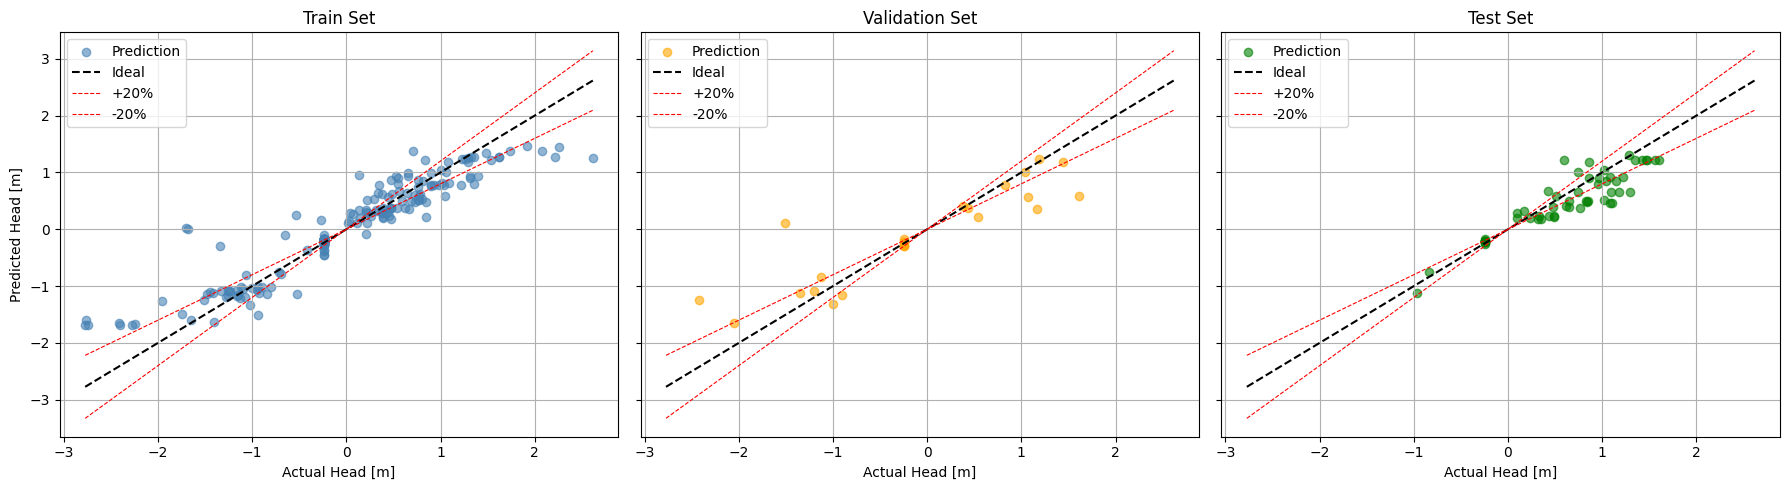

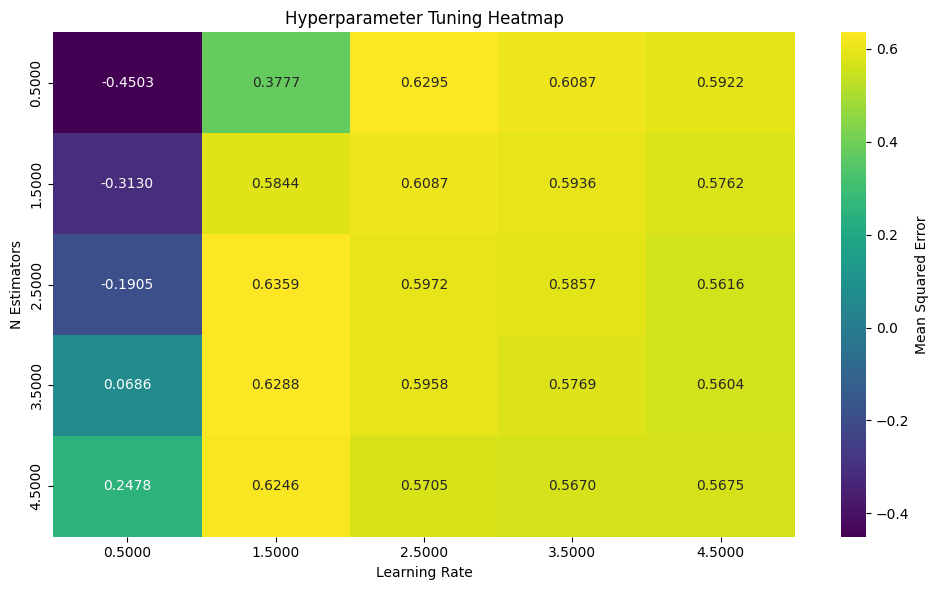

In [130]:
#Train XGBoost new train set (+2 fluids)
xgb_model9, xgb_scores9 = fun.xgboost_with_cv(X_train_scaled9, y_train_scaled9, X_val_scaled9, y_val_scaled9,
                                              X_test_scaled9, y_test_scaled9, param_dist, n_iter, cv_folds, img_name='no')
#Add the model and scores to the list
xgb_modelsGSY.append(xgb_model9)
xgb_scoresGSY.append(xgb_scores9)

**Tenth Iteration**

In [131]:
#Scaled the candidates pool with the same scaler used for nineth iteration
X_candidates_scaled10 = scaler_x9.transform(updated_pool9[feature_cols])

/Users/danielmorantes/PythonP/Tesis_env/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [ ]:
#Select the 2 fluids to simulate
train_sets9 = train_sets[8][feature_cols].copy()
n_selected = 2
fluids_augment, updated_pool10 = fun.greedy_sampling_outputs(xgb_model9, updated_pool9, 
                                                            X_train_scaled9, X_candidates_scaled9, n_selected)
fluids_augment

Selected 2 new candidates:
Remaining pool size: 2980


,rho(kg/m3),k(Pa*s^n),n(-),FluidType,massflow_dim
2576,1003.724206,5.520752,0.347012,PowerLaw,1.342302
2140,1009.065412,6.885243,0.382939,PowerLaw,1.129513


**Data Loading and Preprocesssing**

In [6]:
#Load of the results of the simulations of the selected fluids
file_path = "/Users/danielmorantes/Downloads/DatasetFinal.xlsx"
sheet_name_GSy = 'GSY'
GSy_rawdf10 = fun.load_excel_data(file_path, sheet_name_GSy) 

 Loaded data with shape: (120, 11)
 Loaded Fluids: 20
Dropped columns: ['Liquid', 'Concentration', 'Flow Rate(GPM)', 'Flow Rate[m3/h]', 'Omega(rpm)']


In [7]:
#BEP scaling of the raw selected fluids
entireGSy10, GSy_bepscaled10 = fun.apply_bep_scaling(GSy_rawdf10)
GSy_bepscaled10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   LiquidNo            81 non-null     int64  
 1   rho(kg/m3)          81 non-null     float64
 2   k(Pa*s^n)           81 non-null     float64
 3   n(-)                81 non-null     float64
 4   massflow_dim        81 non-null     float64
 5   torque_dim          81 non-null     float64
 6   hydraulicpower_dim  81 non-null     float64
 7   breakpower_dim      81 non-null     float64
 8   eff_dim             81 non-null     float64
 9   head_dim            81 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 6.5 KB


In [8]:
#Add to the original train set the GSx generated fluids 2 by 2
train_sets, list_fluids = fun.loop_add_fluids_in_order(bepscaled_initial_trainData, GSy_bepscaled10)
train_sets[9] #Look for the Tenth train set (Original + 20 fluids)

Iteration 1: New training set includes 35 unique fluids
Iteration 2: New training set includes 37 unique fluids
Iteration 3: New training set includes 39 unique fluids
Iteration 4: New training set includes 41 unique fluids
Iteration 5: New training set includes 43 unique fluids
Iteration 6: New training set includes 45 unique fluids
Iteration 7: New training set includes 47 unique fluids
Iteration 8: New training set includes 49 unique fluids
Iteration 9: New training set includes 51 unique fluids
Iteration 10: New training set includes 53 unique fluids


,LiquidNo,rho(kg/m3),k(Pa*s^n),n(-),massflow_dim,torque_dim,hydraulicpower_dim,breakpower_dim,eff_dim,head_dim
0,0,997.000000,0.001000,1.000000,0.000000,0.679632,0.000000,0.679633,0.000000,1.290569
1,0,997.000000,0.001000,1.000000,0.250000,0.724184,0.303160,0.724184,0.418623,1.212641
2,0,997.000000,0.001000,1.000000,0.500000,0.812492,0.582448,0.812492,0.716867,1.164897
3,0,997.000000,0.001000,1.000000,0.750000,0.913659,0.824483,0.913659,0.902397,1.099311
4,0,997.000000,0.001000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...
217,52,1009.065412,6.885243,0.382939,0.333333,1.000000,1.000000,1.000000,0.362683,0.848382
218,52,1009.065412,6.885243,0.382939,0.666667,1.000000,1.000000,1.000000,0.860732,1.159562
219,52,1009.065412,6.885243,0.382939,0.946256,1.000000,1.000000,1.000000,0.946093,0.960520
220,52,1009.065412,6.885243,0.382939,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
#Split and scale new train set
X_train_scaled10, X_val_scaled10, X_test_scaled10, y_train_scaled10, y_val_scaled10, y_test_scaled10, scaler_x10, scaler_y10= fun.splitandscale_byfluid(train_sets[9], testdata_bepscaled,
                                                                                                                                                feature_cols, target_cols, val_size)

Split completed: 196 train samples, 26 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.


Fitting 25 folds for each of 500 candidates, totalling 12500 fits
mse_train: 0.1836
r2_train: 0.8164
mse_val: 0.0941
r2_val: 0.8137
mse_test: 0.0661
r2_test: 0.8147
Best hyperparameters: {'subsample': 0.6, 'reg_lambda': 0, 'reg_alpha': 1, 'n_estimators': 700, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 1.0}


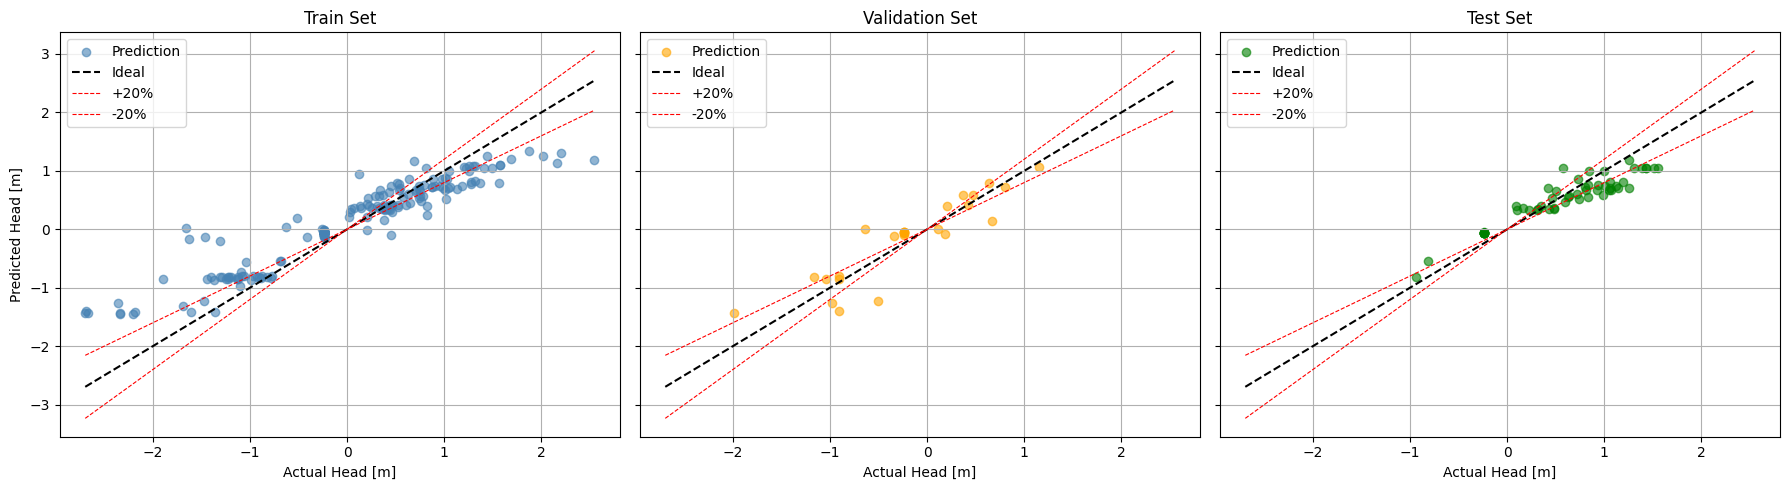

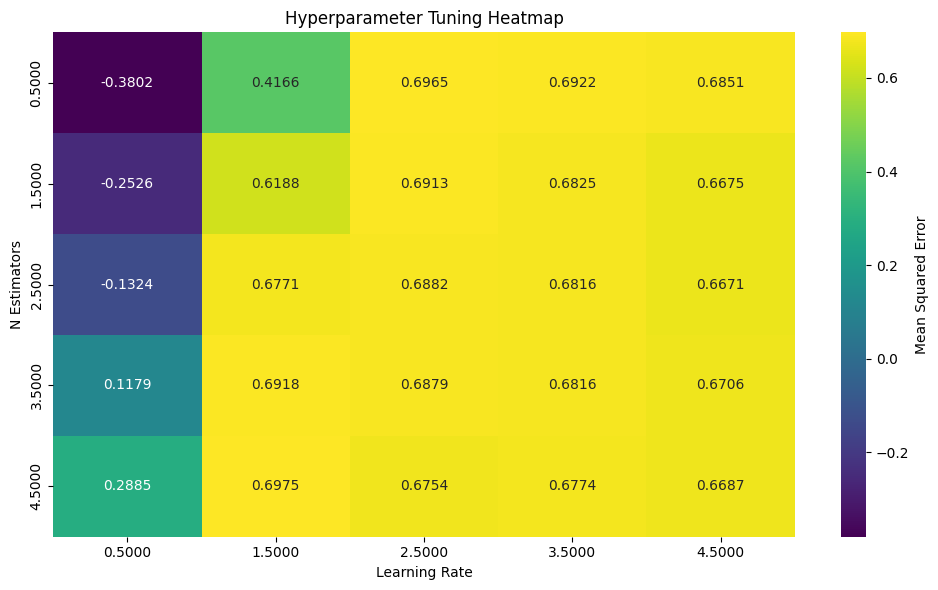

In [138]:
#Train XGBoost new train set (+2 fluids)
xgb_model10, xgb_scores10 = fun.xgboost_with_cv(X_train_scaled10, y_train_scaled10, X_val_scaled10, y_val_scaled10,
                                              X_test_scaled10, y_test_scaled10, param_dist, n_iter, cv_folds, img_name='no')
#Add the model and scores to the list
xgb_modelsGSY.append(xgb_model10)
xgb_scoresGSY.append(xgb_scores10)

In [ ]:
#Retrain XGBoost models with the selected fluids to obtain the final MAE and EV
val_size = 0.1
Xtrain_setsXGB, ytrain_setsXGB, Xval_setsXGB, yval_setsXGB, Xtest_setsXGB, ytest_setsXGB = fun.split_scale_by_fluid_multiple_trainsets(train_sets, testdata_bepscaled, feature_cols, target_cols, val_size)
img_name = 'no'
xgb_models, xgb_scores = fun.train_multiple_XGBoost(Xtrain_setsXGB, ytrain_setsXGB, Xval_setsXGB, yval_setsXGB
                                                        ,Xtest_setsXGB, ytest_setsXGB, param_dist, n_iter, cv_folds, img_name)

Split completed: 133 train samples, 16 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.
Split completed: 140 train samples, 16 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.
Split completed: 143 train samples, 20 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.
Split completed: 152 train samples, 23 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.
Split completed: 160 train samples, 22 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.
Split completed: 166 train samples, 21 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.
Split completed: 174 train samples, 24 validation samples.
Test set size: 57 samples (FIXED TEST SET).
Features and target scaled.
Split completed: 181 train samples, 25 validation samples.
Test set size: 57 sample

# RESULTS

**Results Greedy Sampling on the Outputs XGBoost**

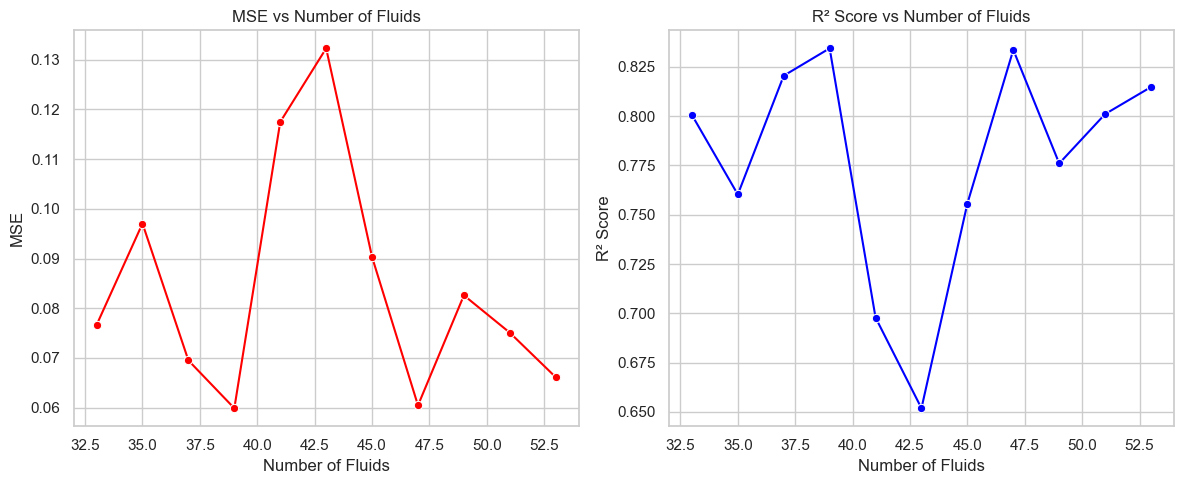

XGBscoresGSY saved in artifacts


In [140]:
#Track the performance while adding fluids
xgb_intresults = joblib.load('artifacts/results_xgbintdata.pkl')
fun.plot_testmetrics_vs_fluids(xgb_intresults, xgb_scoresGSY, list_fluids)
fun.save_object(xgb_scoresGSY, 'XGBscoresGSY')